In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager
from kernel_extraction.kernel_extractor import KernelExtractorManager

In [3]:
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)
kernel_manager = KernelExtractorManager(subdataset_filtered, patch_size=32)
kernels_dataset = kernel_manager.extract_all(patches_per_lesion=3)

Cargando subconjunto de datos (Primeras 1000 imágenes)...
  -> Cargado subconjunto Bleeding: (1000, 512, 512)
  -> Cargado subconjunto Ischemia: (1000, 512, 512)
  -> Cargado subconjunto Normal: (1000, 512, 512)
Iniciando extracción de cerebros...
  -> Procesando clase: Bleeding (1000 imágenes)
  -> Procesando clase: Ischemia (1000 imágenes)
  -> Procesando clase: Normal (1000 imágenes)
Extracción completada.
Iniciando extracción de kernels (32x32)...
  -> Procesando Bleeding...
  -> Procesando Ischemia...

  -> Balanceando patologías al mínimo común: 2884 parches.
  -> Procesando Normal (Buscando 2884 parches para balance 1:1:1)...
--------------------------------------------------
RESUMEN DE KERNELS EXTRAÍDOS (BALANCE ESTRICTO 1:1:1):
[Bleeding]: 2884 parches de tamaño 32x32
[Ischemia]: 2884 parches de tamaño 32x32
[Normal]: 2884 parches de tamaño 32x32
--------------------------------------------------


## Feature Extractor
Obtengo Kernels de 32x32 de cada tejido:
- Normal: proviene de 'brain' (tejido sano).
- Ischemia/Bleeding: proviene de 'overlay' (tejido no sano).

In [4]:
from feature_analysis.utils import save_kernels_dataset, plot_feature_distributions
from feature_analysis.feature_extract import FeatureExtractManager

In [5]:
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


Generando gráficos estadísticos...


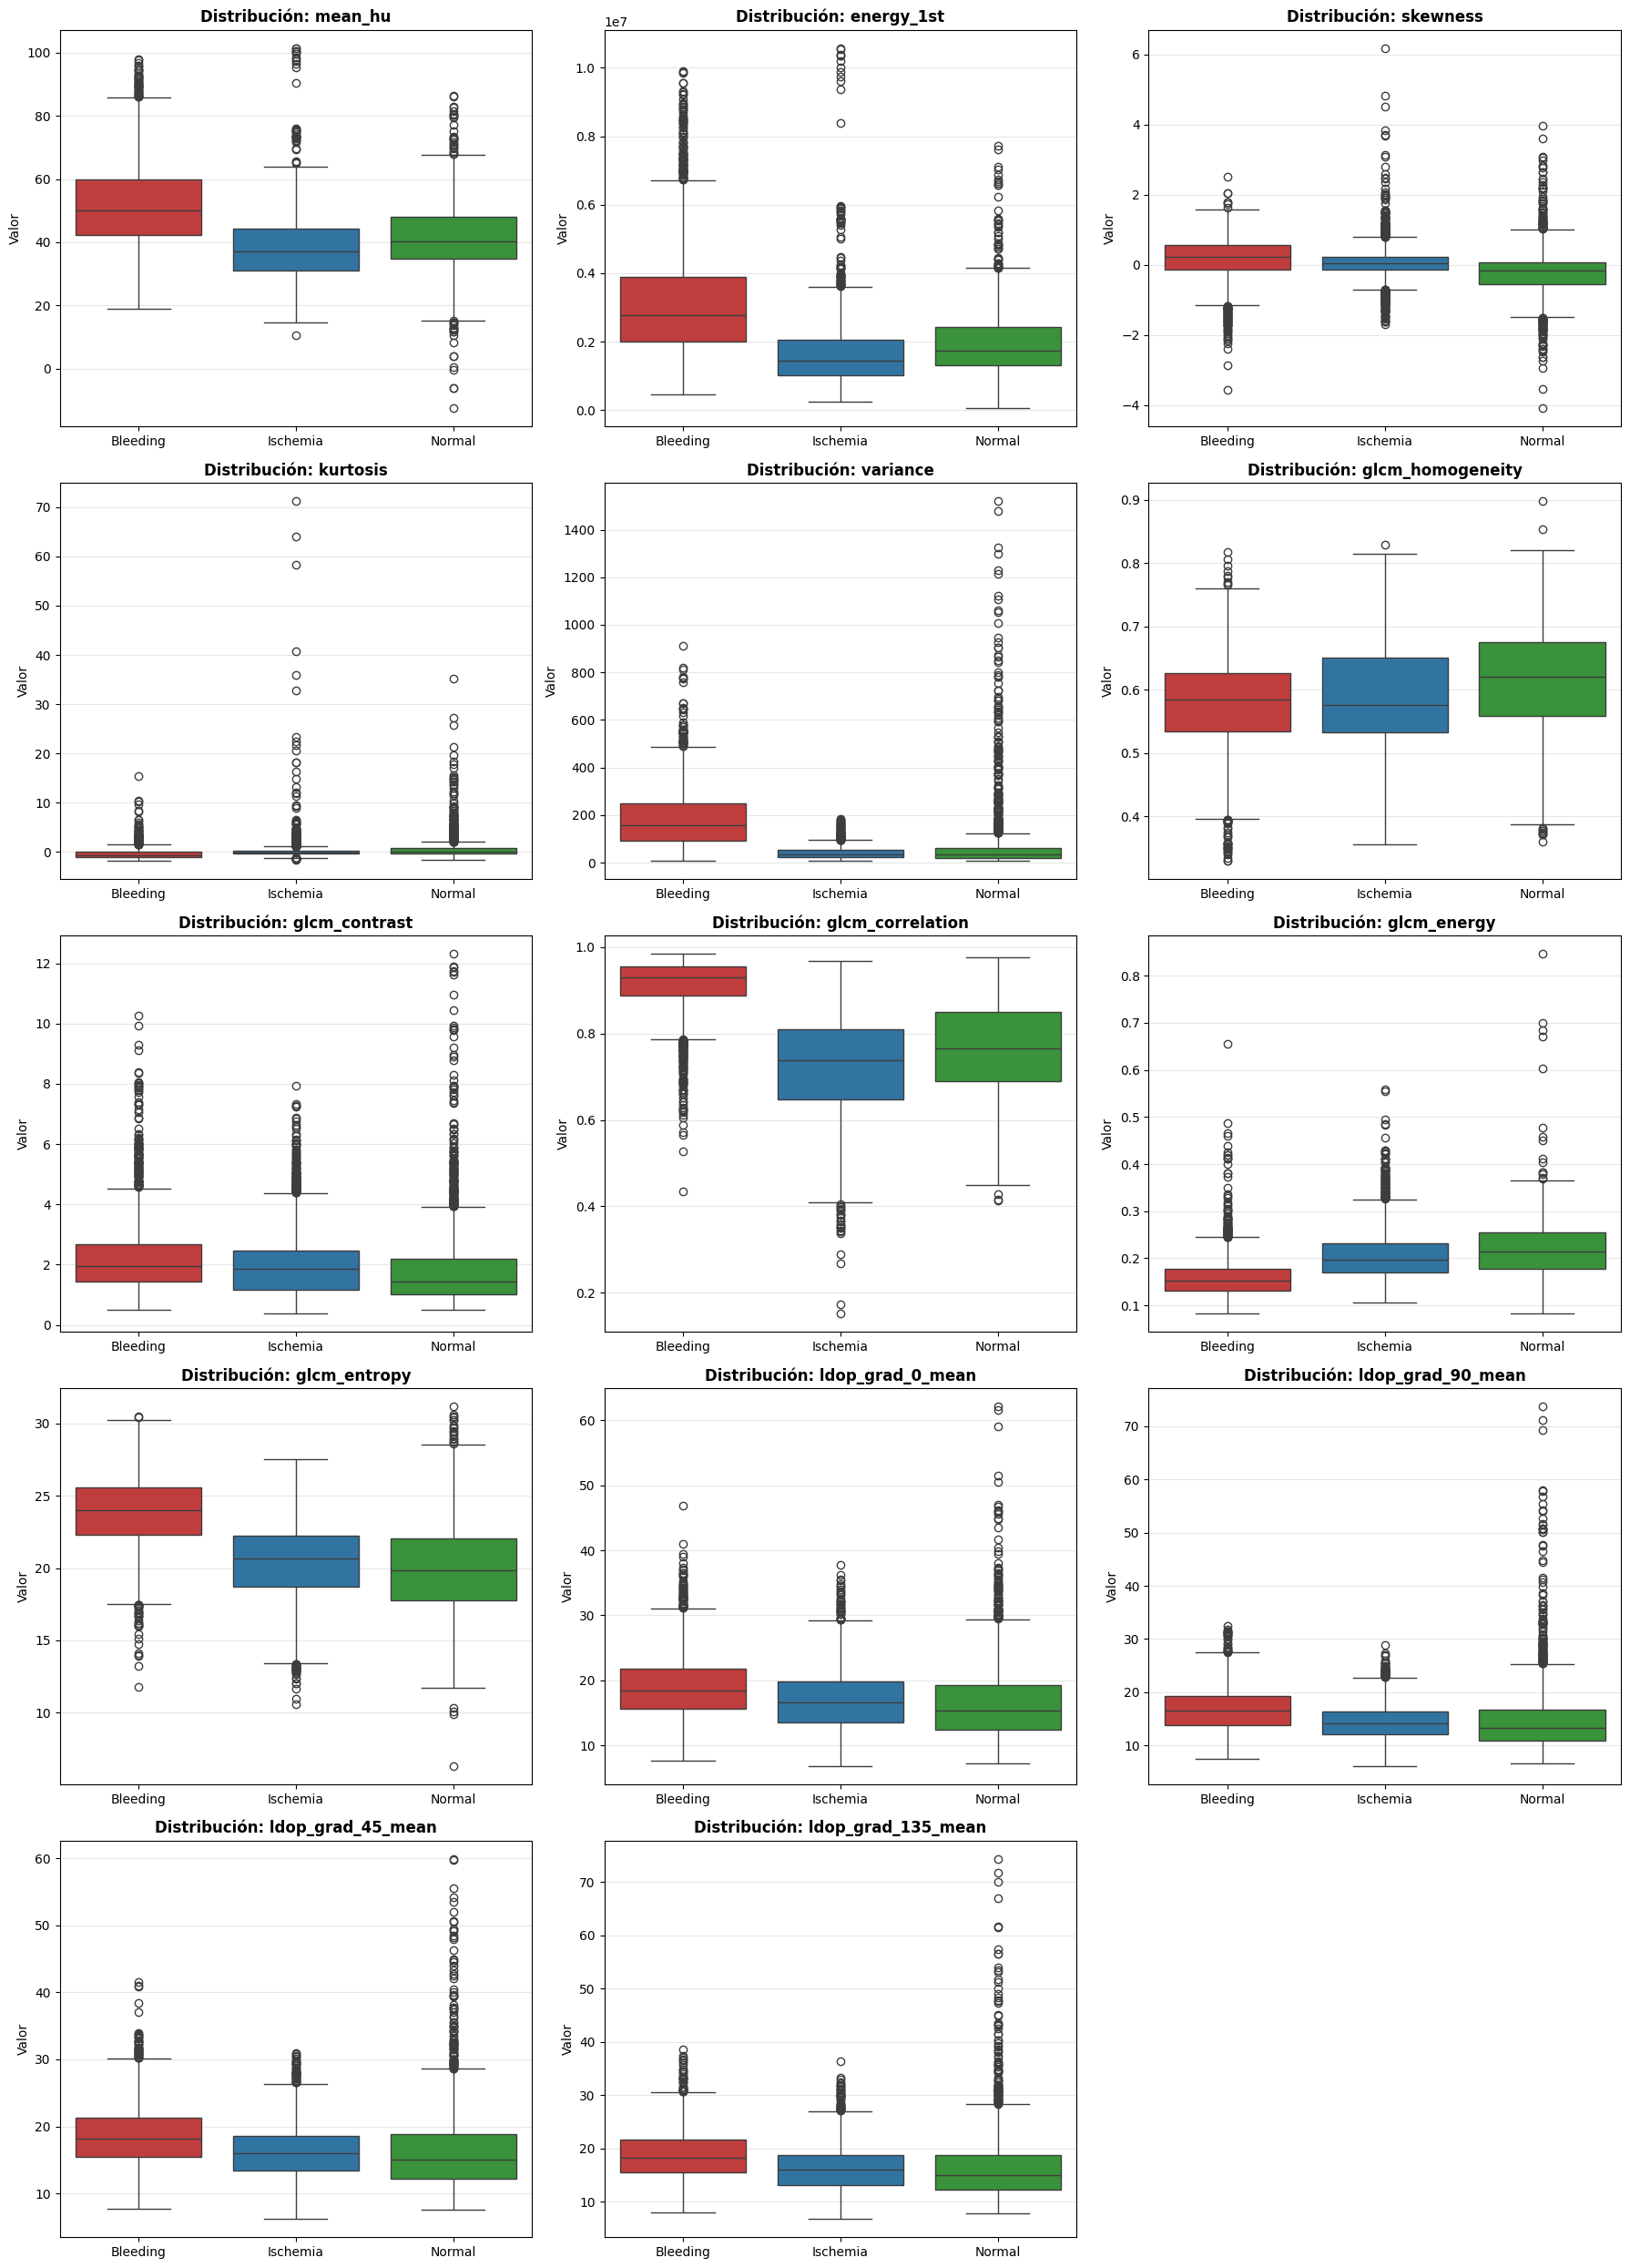

In [6]:
plot_feature_distributions(df_features)

# Almacenamiento del Kernel
Para no volver a correr los códigos para general los kernels (que lleva su tiempo) lo almaceno como NumPy.

In [7]:
save_kernels_dataset(kernels_dataset)

--------------------------------------------------
ÉXITO: Dataset de kernels guardado en '..\Kernels_datasets_numpy\kernel_dataset_2.npy'
--------------------------------------------------


WindowsPath('../Kernels_datasets_numpy/kernel_dataset_2.npy')

# Análisis de Características
Ahora analizo que features son mejores para entrenar al modelo.
- primero, a partir de un pequeño Random-Forest, veo que features tienen mejor Score.
- segundo, a partir de la correlación de Pearson, veo si hay features que brindan la misma información (lo que puede confundir al modelo).


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     0.998016    0.320449        0.125921
1     glcm_correlation     0.990811    0.314559        0.126422
2           energy_1st     0.604947    0.159801        0.089913
3         glcm_entropy     0.585415    0.190325        0.072933
4              mean_hu     0.559064    0.137268        0.087202
5             kurtosis     0.535265    0.154449        0.074406
6             skewness     0.498188    0.091072        0.090035
7          glcm_energy     0.471212    0.161924        0.055262
8    ldop_grad_90_mean     0.352738    0.090701        0.053405
9     glcm_homogeneity     0.289122    0.051737        0.052692
10   ldop_grad_45_mean     0.282477    0.071143        0.043356
11       glcm_contrast     0.264903    0.050258        0.047152
12  ldop_grad_135_mean     0.263971    0.055959        0.044667
13    ldop_grad_0_mean     0.228609    0.053654        0.036635


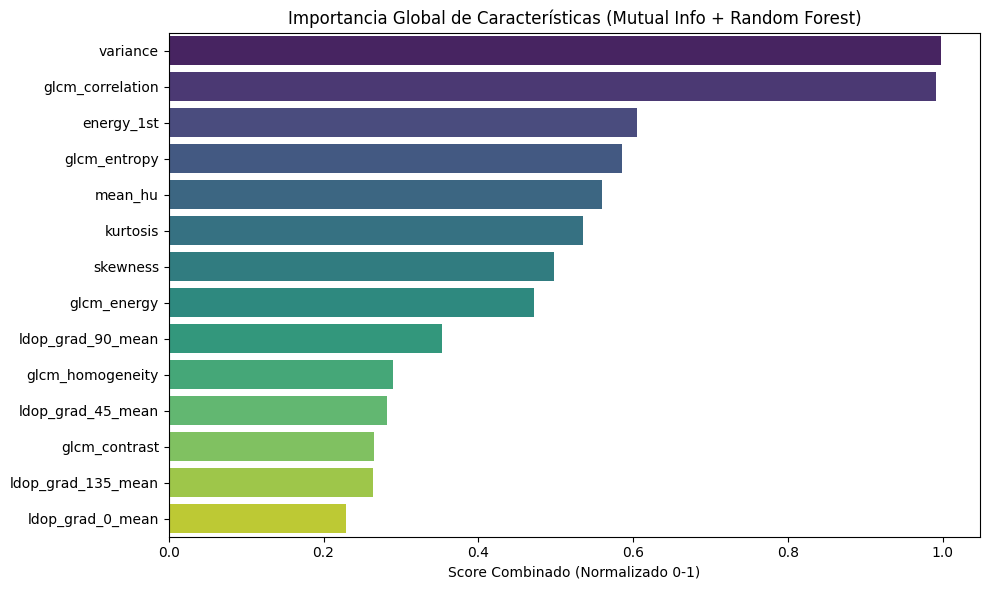

Calculando matriz de correlación cruzada...


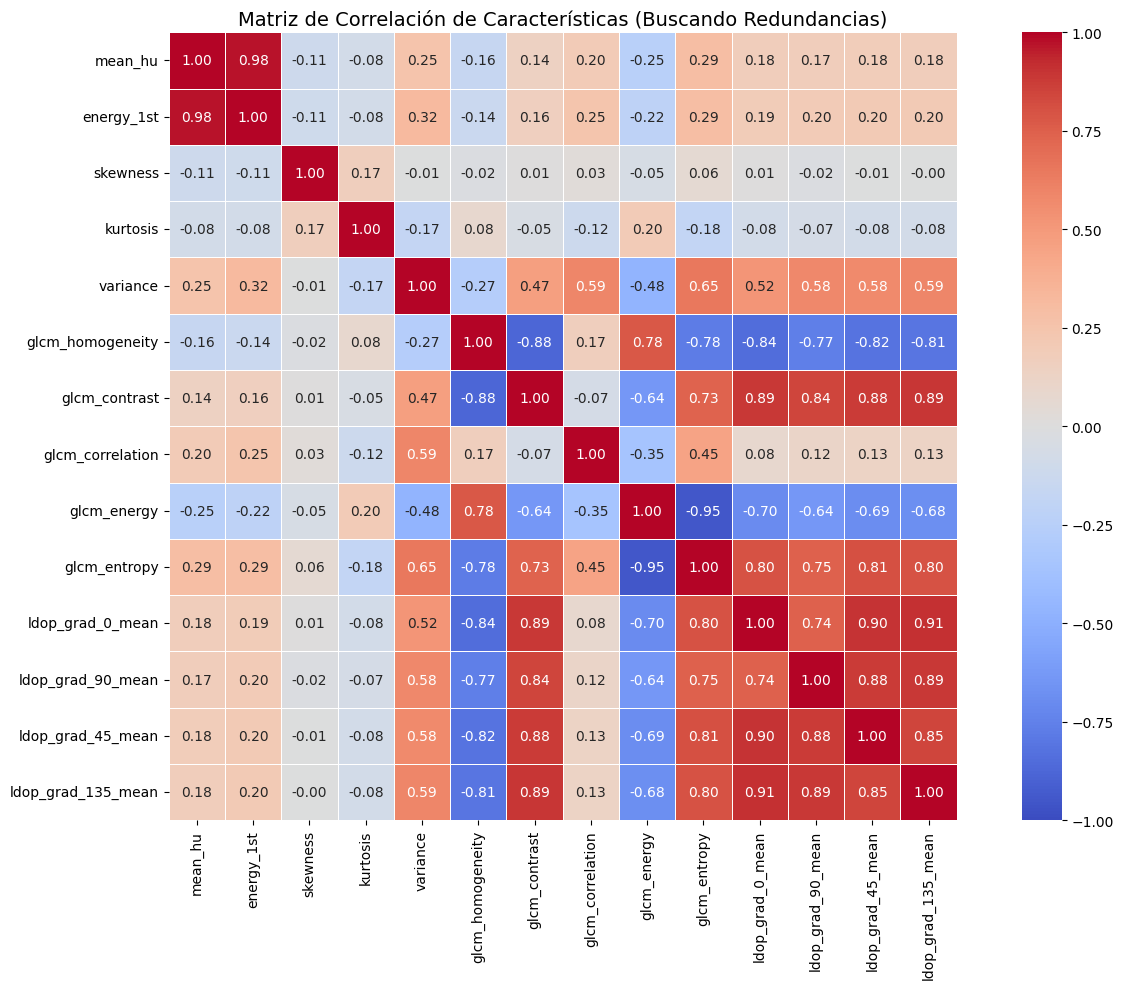

In [8]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis = True)